In [1]:
# loops over datasets of heights, builds histograms, 
# fits a Gaussian to the main peak to estimate its mean and width, 
# then uses that fit to compute peak properties (centroid and FWHM) 
# and visualize the data with the fitted curve and peak region.
# from scipy.optimize import curve_fit

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

bin_edges_fit = np.linspace(0, 8, 180)

for fname, heights in all_heights.items():
    counts, edges   = np.histogram(heights, bins=bin_edges_fit)
    bin_centres     = (edges[:-1] + edges[1:]) / 2
    peak_bin_idx    = np.argmax(counts)
    peak_x          = bin_centres[peak_bin_idx]
    peak_count      = counts[peak_bin_idx]
    half_max        = peak_count / 2

    n_left_bins = int(0.03 * (len(bin_edges_fit) - 1))
    left_cutoff = peak_x - n_left_bins * (bin_edges_fit[1] - bin_edges_fit[0])
    left_mask   = (bin_centres < peak_x) & (bin_centres >= left_cutoff)
    right_mask  =  bin_centres >= peak_x
    fit_mask    = left_mask | right_mask

    x_fit_data = bin_centres[fit_mask]
    y_fit_data = counts[fit_mask] / peak_count

    try:
        popt, pcov = curve_fit(gaussian, x_fit_data, y_fit_data,
                               p0=[peak_x, 0.5], maxfev=10000)
        mu, sigma = popt
        sigma        = abs(sigma)
        peak_min     = mu - 2.5 * sigma
        peak_max     = mu + 2.5 * sigma
        mask         = (heights >= peak_min) & (heights <= peak_max)
        peak_values  = heights[mask]
        centroid     = float(np.mean(peak_values))
        fwhm         = 2.3548 * sigma

        x_curve = np.linspace(0, 8, 500)
        y_curve = peak_count * gaussian(x_curve, mu, sigma)

        fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
        ax.hist(heights, bins=bin_edges_fit, color='steelblue',
                edgecolor='none', label='Data')
        ax.bar(bin_centres[fit_mask], counts[fit_mask],
               width=bin_edges_fit[1] - bin_edges_fit[0],
               color='cornflowerblue', edgecolor='none', label='Bins used for fit')
        ax.plot(x_curve, y_curve, color='crimson', linewidth=2,
                label=f'Gaussian fit (μ={mu:.3f}, σ={sigma:.3f}) mV')
        ax.axhline(half_max, color='grey', linewidth=1, linestyle=':',
                   label=f'Half-maximum ({half_max:.0f} counts)')
        ax.axvline(centroid, color='orange', linewidth=1.5, linestyle='--',
                   label=f'Centroid = {centroid:.4f} mV')
        ax.axvspan(peak_min, peak_max, alpha=0.1, color='crimson',
                   label=f'Peak window (μ ± 2.5σ)')
        ax.set_xlabel('Pulse Height (mV)', fontweight='bold')
        ax.set_ylabel('Frequency',         fontweight='bold')
        ax.set_title(f'Gaussian Fit — {fname}')
        ax.set_xlim(0, 8)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

    except RuntimeError:
        print(f'  Gaussian fit failed for {fname}')

NameError: name 'np' is not defined

In [3]:
import pickle
import os
import numpy as np

# ── Load saved results ────────────────────────────────────────────────────────
save_filename = 'Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0001_0441_saved_results.pkl'
save_path = os.path.join('Shaping Pulse Analysis', save_filename)

with open(save_path, 'rb') as f:
    data = pickle.load(f)

centroid_results = data['centroid_results']
all_heights      = data['all_heights']
hdf5_files       = data['hdf5_files']

print(f'Loaded {len(centroid_results)} files')

Loaded 441 files



Processing file 1/1: Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0248.hdf5
active_channels [0 3]
channel_a_PHAToggled False
channel_a_active True
channel_a_channel_id 0
channel_a_coupling 1
channel_a_live_view True
channel_a_name a
channel_a_offset 100
channel_a_pha_active False
channel_a_range 2
channel_a_verified True
channel_a_waveformsToggled True
channel_b_PHAToggled False
channel_b_active False
channel_b_channel_id 1
channel_b_coupling 1
channel_b_live_view False
channel_b_name b
channel_b_offset 0.0
channel_b_pha_active False
channel_b_range 0
channel_b_verified True
channel_b_waveformsToggled False
channel_c_PHAToggled False
channel_c_active False
channel_c_channel_id 2
channel_c_coupling 1
channel_c_live_view False
channel_c_name c
channel_c_offset 0.0
channel_c_pha_active False
channel_c_range 0
channel_c_verified True
channel_c_waveformsToggled False
channel_d_PHAToggled True
channel_d_active True
channel_d_channel_id 3
channel_d_coupling 1
channel_d_live_view True
c

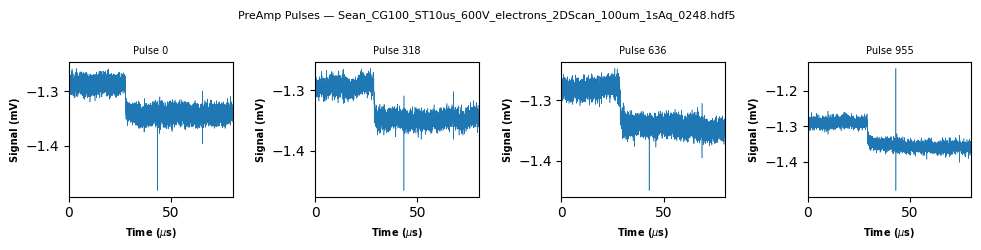

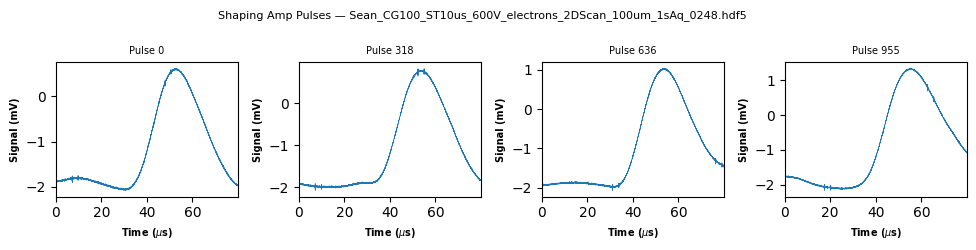

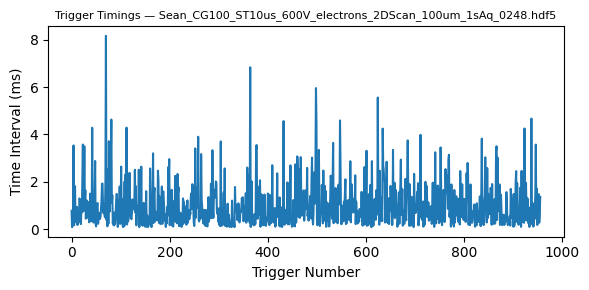

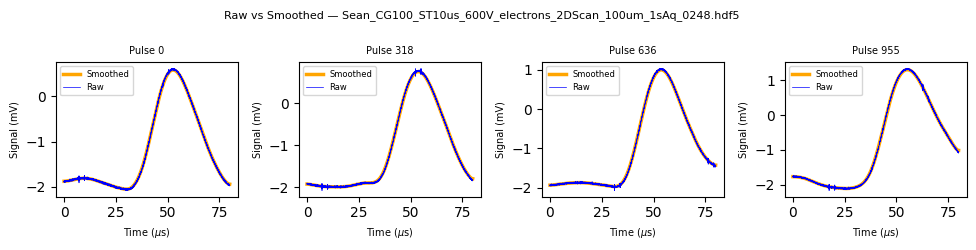

  Found 956 peaks


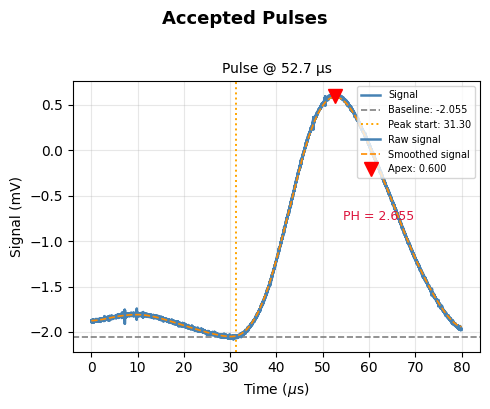

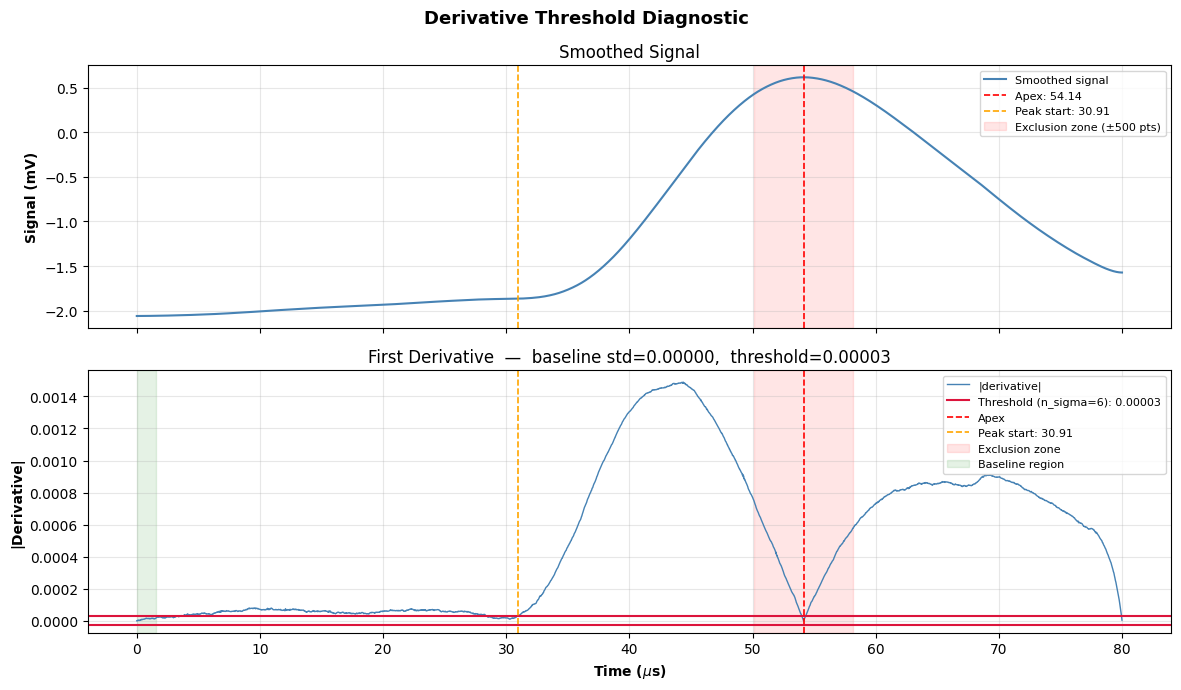

  Accepted: 956,  Rejected: 0


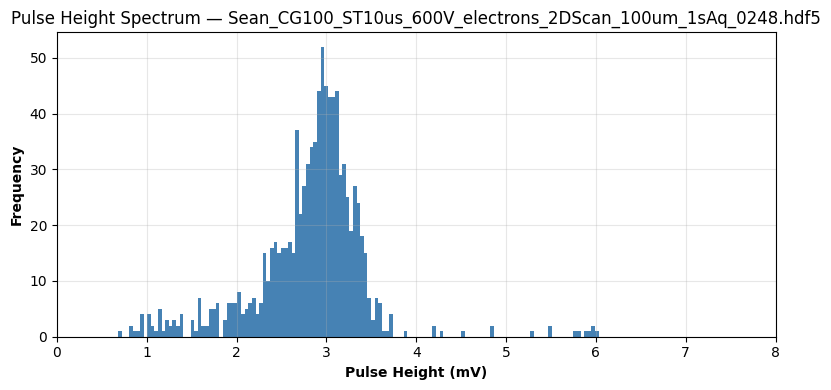

  Gaussian: μ = 3.0095 mV,  σ = 0.2342 mV
  Window  : 2.4241 – 3.5948 mV  (μ ± 2.5σ)
  Centroid: 2.9778 mV


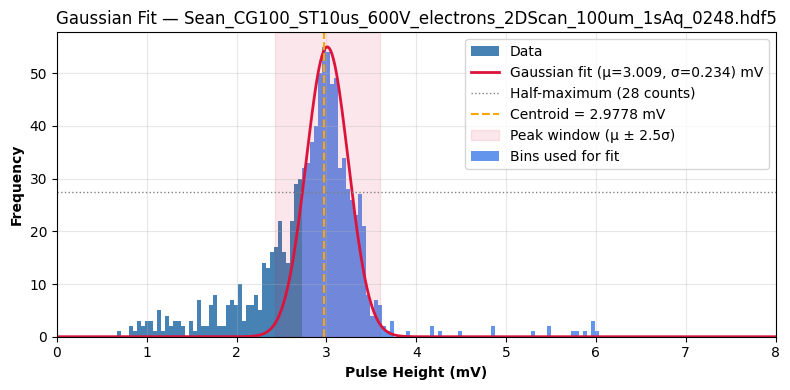

"\n# ── Output folder ─────────────────────────────────────────────────────────────\nimport pickle\nimport csv\nimport os\nfrom datetime import date\n\noutput_folder = 'Shaping Pulse Analysis'\n\nfirst = hdf5_files[0].replace('.hdf5', '')\nlast  = hdf5_files[-1].replace('.hdf5', '').split('_')[-1]\n\n# ── Save pickle file ──────────────────────────────────────────────────────────\nsave_data = {\n    'centroid_results': centroid_results,\n    'all_heights':      all_heights,\n    'hdf5_files':       hdf5_files\n}\n\nsave_filename = os.path.join(output_folder, f'{first}_{last}_saved_results.pkl')\nwith open(save_filename, 'wb') as f:\n    pickle.dump(save_data, f)\nprint(f'Results saved to: {save_filename}')\n\n\n# ── Export centroids to CSV ───────────────────────────────────────────────────\nheaders = ['Index', 'Filename', 'Peak Height (mV)', 'Centroid (mV)', 'Centroid SEM (mV)',\n           'FWHM (mV)', 'Peak Resolution (%)', 'N Pulses', 'Gaussian Mean μ (mV)', 'Chi2 Reduced']\n\ncsv_

In [68]:
import numpy as np
import h5py
import sys
import random
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import openpyxl
import importlib
importlib.reload(Shaping_amp)

sys.path.append(r'C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data')
from Functions import Shaping_amp
from Functions import DataSmoothingShaping

import importlib
from Functions import Shaping_amp
importlib.reload(Shaping_amp)

# ── File list ────────────────────────────────────────────────────────────────
hdf5_files = [f'Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0248.hdf5'] # {i}.hdf5' for i in range(1, 31)]
# replace {i} with {i:04d} for file format ending _0001 etc

# ── Helpers ──────────────────────────────────────────────────────────────────
def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def time_axis_from_metadata(timebase, n_points):
    t = (timebase - 3) * 16 if timebase > 4 else (2 ** timebase)
    return np.arange(0, t * n_points, t) / 1e3   # µs

# ── Per-file processing ───────────────────────────────────────────────────────
centroid_results = []   
all_heights      = {}

for file_idx, filepath in enumerate(hdf5_files):

    print(f'\n{"="*60}')
    print(f'Processing file {file_idx + 1}/{len(hdf5_files)}: {filepath}')
    print('='*60)

    # ── Load data ────────────────────────────────────────────────────────────
    try:
        with h5py.File(filepath, 'r') as f:
            Timebase = f['/metadata'].attrs['timebase']
            ChARange = f['/metadata'].attrs['channel_a_range']
            ChDRange = f['/metadata'].attrs['channel_d_range']
            if file_idx == 0:
                for attr_name in f['/metadata'].attrs:
                    print(attr_name, f['/metadata'].attrs[attr_name])
            PreAmpPulses     = np.array(f['adc_counts_0'])
            ShapingAmpPulses = np.array(f['adc_counts_3'])
            TriggerTimings   = np.array(f['trigger_timings'])

        if PreAmpPulses.shape[0] == 0:
            raise ValueError('Empty array')

    except Exception as e:
        print(f'  Skipping {filepath}: {e}')
        centroid_results.append((filepath, 'no pulses', 'no pulses', 'no pulses',
                                 'no pulses', 'no pulses', 0, 'no pulses', 'no pulses'))
        continue

    N_Captures   = len(PreAmpPulses)
    N_Datapoints = PreAmpPulses.shape[1]
    Time_us      = time_axis_from_metadata(Timebase, N_Datapoints)

    print(f'  Captures: {N_Captures},  Datapoints/pulse: {N_Datapoints}')

    # ── Convert ADC → mV ─────────────────────────────────────────────────────
    PreAmpPulses_mV     = PreAmpPulses     * ChARange / 32767
    ShapingAmpPulses_mV = ShapingAmpPulses * ChDRange / 32767

    # ── 4 example PreAmp pulses ───────────────────────────────────────────────
    ExampleIdx = np.linspace(0, N_Captures - 1, 4, dtype=int)
    fig, axes  = plt.subplots(1, 4, figsize=(10, 2.5), tight_layout=True)
    fig.suptitle(f'PreAmp Pulses — {filepath}', fontsize=8)
    for i, ax in enumerate(axes):
        ax.plot(Time_us, PreAmpPulses_mV[ExampleIdx[i]], linewidth=0.4)
        ax.set_xlabel(r'Time ($\mu$s)', fontweight='bold', fontsize=7)
        ax.set_ylabel('Signal (mV)',    fontweight='bold', fontsize=7)
        ax.set_xlim(0, Time_us[-1])
        ax.set_title(f'Pulse {ExampleIdx[i]}', fontsize=7)
    plt.show()

    # ── 4 example Shaping Amp pulses ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.5), tight_layout=True)
    fig.suptitle(f'Shaping Amp Pulses — {filepath}', fontsize=8)
    for i, ax in enumerate(axes):
        ax.plot(Time_us, ShapingAmpPulses_mV[ExampleIdx[i]], linewidth=0.4)
        ax.set_xlabel(r'Time ($\mu$s)', fontweight='bold', fontsize=7)
        ax.set_ylabel('Signal (mV)',    fontweight='bold', fontsize=7)
        ax.set_xlim(0, Time_us[-1])
        ax.set_title(f'Pulse {ExampleIdx[i]}', fontsize=7)
    plt.show()
    

    # ── Trigger timings ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
    ax.plot(TriggerTimings * 1000)
    ax.set_xlabel('Trigger Number')
    ax.set_ylabel('Time Interval (ms)')
    ax.set_title(f'Trigger Timings — {filepath}', fontsize=8)
    plt.show()

    # ── Smooth all shaping amp pulses ─────────────────────────────────────────
    SmoothedShapingPulses = np.array(DataSmoothingShaping.WhittakerSmooth(
        ShapingAmpPulses_mV, lmbd=1e4, order=1
    ))

    # ── 4 example raw vs smoothed ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.5), tight_layout=True)
    fig.suptitle(f'Raw vs Smoothed — {filepath}', fontsize=8)
    for i, ax in enumerate(axes):
        ax.plot(Time_us, SmoothedShapingPulses[ExampleIdx[i]],
                color='orange', linewidth=2.5, label='Smoothed')
        ax.plot(Time_us, ShapingAmpPulses_mV[ExampleIdx[i]],
                color='blue',   linewidth=0.5, label='Raw')
        ax.set_xlabel(r'Time ($\mu$s)', fontsize=7)
        ax.set_ylabel('Signal (mV)',    fontsize=7)
        ax.set_title(f'Pulse {ExampleIdx[i]}', fontsize=7)
        ax.legend(fontsize=6, loc='best')
    plt.show()

    # ── Peak finding ──────────────────────────────────────────────────────────
    PeakIndex = np.array([np.argmax(pulse) for pulse in SmoothedShapingPulses])
    print(f'  Found {len(PeakIndex)} peaks')

    # ── accepted-pulse plots ─────────────────────────────────────────
    n_plots = 1  # <-- set how many pulses you want

    # Generate evenly spaced indices across all captures
    indices = np.linspace(0, N_Captures - 1, n_plots, dtype=int)

    for idx in indices:
        Shaping_amp.plot_accepted_pulses(
            data=ShapingAmpPulses_mV[idx],
            smoothed_data=SmoothedShapingPulses[idx],
            accepted_peaks=[int(PeakIndex[idx])],
            threshold=6,
            window_size=200,
            time_axis=Time_us,
        )

    # ── Derivative threshold diagnostic ──────────────────────────────────────
    mid_idx = len(SmoothedShapingPulses) // 2
    
    Shaping_amp.plot_derivative_threshold(
        smoothed_data        = SmoothedShapingPulses[mid_idx],
        peak_index           = int(PeakIndex[mid_idx]),
        n_sigma              = 6,
        min_baseline_samples = 200,
        window               = 50,
        apex_exclusion_window= 500,
        time_axis            = Time_us,
    )

        
    # ── Extract pulse heights ─────────────────────────────────────────────────
    MIN_PULSE_HEIGHT = 0.1   # mV
    all_pulse_heights = []
    accepted_count    = 0
    rejected_count    = 0

    for i, single_peak in enumerate(PeakIndex):
        ph, *_ = Shaping_amp.find_pulse_height(
            raw_data=np.array(ShapingAmpPulses_mV[i]).flatten(),
            smoothed_data=np.array(SmoothedShapingPulses[i]).flatten(),
            peak_index=int(single_peak),
            n_sigma=6,
            min_baseline_samples=200,
            baseline_window=200,
        )
        if ph is None or np.isnan(ph) or abs(ph) < MIN_PULSE_HEIGHT:
            rejected_count += 1
        else:
            all_pulse_heights.append(ph)
            accepted_count += 1

    print(f'  Accepted: {accepted_count},  Rejected: {rejected_count}')

    heights   = np.abs(all_pulse_heights)
    all_heights[filepath] = heights
    bin_edges = np.linspace(0, 8, 200)

    # ── Pulse height histogram ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
    ax.hist(heights, bins=bin_edges, color='steelblue', edgecolor='none')
    ax.set_xlabel('Pulse Height (mV)', fontweight='bold')
    ax.set_ylabel('Frequency',         fontweight='bold')
    ax.set_title(f'Pulse Height Spectrum — {filepath}')
    ax.set_xlim(0, 8)
    ax.grid(True, alpha=0.3)
    plt.show()

    # ── Gaussian fit & centroid ───────────────────────────────────────────────
    # Building the histogram
    bin_edges_fit   = np.linspace(0, 8, 180)
    counts, edges   = np.histogram(heights, bins=bin_edges_fit)
    bin_centres     = (edges[:-1] + edges[1:]) / 2

    # Finding the peak
    peak_bin_idx = np.argmax(counts)
    peak_x       = bin_centres[peak_bin_idx]
    peak_count   = counts[peak_bin_idx]
    half_max     = peak_count / 2 # used later for the FWHM 

    # Defining which bins to fit
    # Deliberately asymmetric: 3% of the range to the left of the peak (~5 bins) but all bins to the right.
    # This is intentional because of the low-energy tail on the left.
    n_left_bins = int(0.03 * (len(bin_edges_fit) - 1))  
    left_cutoff = peak_x - n_left_bins * (bin_edges_fit[1] - bin_edges_fit[0])
    left_mask   = (bin_centres < peak_x) & (bin_centres >= left_cutoff)
    right_mask  =  bin_centres >= peak_x
    fit_mask    = left_mask | right_mask

    x_fit_data = bin_centres[fit_mask]
    y_fit_data = counts[fit_mask] / peak_count

    centroid     = np.nan
    centroid_SEM = np.nan
    fwhm         = np.nan
    resolution   = np.nan
    chi2_reduced = np.nan
    try:
        popt, pcov = curve_fit(gaussian, x_fit_data, y_fit_data,
                            p0=[peak_x, 0.5], maxfev=10000)
        mu, sigma = popt
        sigma = abs(sigma)

        mu_err       = np.sqrt(pcov[0, 0])
        peak_min     = mu - 2.5 * sigma
        peak_max     = mu + 2.5 * sigma
        mask         = (heights >= peak_min) & (heights <= peak_max)
        peak_values  = heights[mask]
        centroid     = float(np.mean(peak_values))
        centroid_SEM = float(np.std(peak_values, ddof=1) / np.sqrt(len(peak_values)))
        fwhm         = 2.3548 * sigma
        resolution   = fwhm / mu

        # ── Reduced chi-squared ──────────────────────────────────────────
        y_predicted  = peak_count * gaussian(bin_centres[fit_mask], mu, sigma)
        y_observed   = counts[fit_mask].astype(float)
        residuals    = y_observed - y_predicted
        chi2         = np.sum((residuals / np.sqrt(np.maximum(y_observed, 1)))**2)
        dof          = len(y_observed) - 2
        chi2_reduced = chi2 / dof
        # ────────────────────────────────────────────────────────────────

        print(f'  Gaussian: μ = {mu:.4f} mV,  σ = {sigma:.4f} mV')
        print(f'  Window  : {peak_min:.4f} – {peak_max:.4f} mV  (μ ± 2.5σ)')
        print(f'  Centroid: {centroid:.4f} mV')

        x_curve = np.linspace(0, 8, 500)
        y_curve = peak_count * gaussian(x_curve, mu, sigma)

        fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
        ax.hist(heights, bins=bin_edges_fit, color='steelblue',
                edgecolor='none', label='Data')
        ax.bar(bin_centres[fit_mask], counts[fit_mask],
               width=bin_edges_fit[1] - bin_edges_fit[0],
               color='cornflowerblue', edgecolor='none', label='Bins used for fit')
        ax.plot(x_curve, y_curve, color='crimson', linewidth=2,
                label=f'Gaussian fit (μ={mu:.3f}, σ={sigma:.3f}) mV')
        ax.axhline(half_max, color='grey', linewidth=1, linestyle=':',
                   label=f'Half-maximum ({half_max:.0f} counts)')
        ax.axvline(centroid, color='orange', linewidth=1.5, linestyle='--',
                   label=f'Centroid = {centroid:.4f} mV')
        ax.axvspan(peak_min, peak_max, alpha=0.1, color='crimson',
                   label=f'Peak window (μ ± 2.5σ)')
        ax.set_xlabel('Pulse Height (mV)', fontweight='bold')
        ax.set_ylabel('Frequency',         fontweight='bold')
        ax.set_title(f'Gaussian Fit — {filepath}')
        ax.set_xlim(0, 8)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

    except RuntimeError:
        print(f'  Gaussian fit failed for {filepath}')

    centroid_results.append((filepath, centroid, centroid_SEM, peak_x, fwhm, resolution, N_Captures, mu if not np.isnan(centroid) else np.nan, chi2_reduced))
"""
# ── Output folder ─────────────────────────────────────────────────────────────
import pickle
import csv
import os
from datetime import date

output_folder = 'Shaping Pulse Analysis'

first = hdf5_files[0].replace('.hdf5', '')
last  = hdf5_files[-1].replace('.hdf5', '').split('_')[-1]

# ── Save pickle file ──────────────────────────────────────────────────────────
save_data = {
    'centroid_results': centroid_results,
    'all_heights':      all_heights,
    'hdf5_files':       hdf5_files
}

save_filename = os.path.join(output_folder, f'{first}_{last}_saved_results.pkl')
with open(save_filename, 'wb') as f:
    pickle.dump(save_data, f)
print(f'Results saved to: {save_filename}')


# ── Export centroids to CSV ───────────────────────────────────────────────────
headers = ['Index', 'Filename', 'Peak Height (mV)', 'Centroid (mV)', 'Centroid SEM (mV)',
           'FWHM (mV)', 'Peak Resolution (%)', 'N Pulses', 'Gaussian Mean μ (mV)', 'Chi2 Reduced']

csv_filename = os.path.join(output_folder, f'{first}_{last}_centroids.csv')

with open(csv_filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(headers)

    for row_idx, (fname, cent, centroid_SEM, peak_val, fwhm, resolution, n_pulses, mu, chi2_reduced) in enumerate(centroid_results, start=1):
        row = [row_idx, fname]

        for val in [peak_val, cent, centroid_SEM, fwhm, resolution]:
            if isinstance(val, str):
                row.append(val)
            else:
                row.append(round(float(val), 6) if not np.isnan(val) else 'FIT FAILED')

        row.append(n_pulses)

        if isinstance(mu, str):
            row.append('no pulses')
        else:
            row.append(round(float(mu), 6) if not np.isnan(mu) else 'FIT FAILED')

        if isinstance(chi2_reduced, float) and not np.isnan(chi2_reduced):
            row.append(round(chi2_reduced, 4))
        else:
            row.append('FIT FAILED')

        writer.writerow(row)

print(f'Centroid results saved to: {csv_filename}')
print(f'All outputs written to folder: {output_folder}')
"""

In [84]:
# ── Define your pulse height range ───────────────────────────────────────────
PH_MIN = 1   # mV  <-- set your lower bound
PH_MAX = 2.5   # mV  <-- set your upper bound

# Collect (index, pulse_height) for pulses within the range
in_range_indices = []

for i, single_peak in enumerate(PeakIndex):
    ph, *_ = Shaping_amp.find_pulse_height(
        raw_data=np.array(ShapingAmpPulses_mV[i]).flatten(),
        smoothed_data=np.array(SmoothedShapingPulses[i]).flatten(),
        peak_index=int(single_peak),
        n_sigma=6,
        min_baseline_samples=200,
        baseline_window=200,
    )
    if ph is None or np.isnan(ph) or abs(ph) < MIN_PULSE_HEIGHT:
        continue
    if PH_MIN <= abs(ph) <= PH_MAX:
        in_range_indices.append((i, abs(ph)))

print(f"Pulses in range [{PH_MIN}, {PH_MAX}] mV: {len(in_range_indices)}")

Pulses in range [1, 2.5] mV: 197


  Capture     3 | pulse height = 1.1344 mV


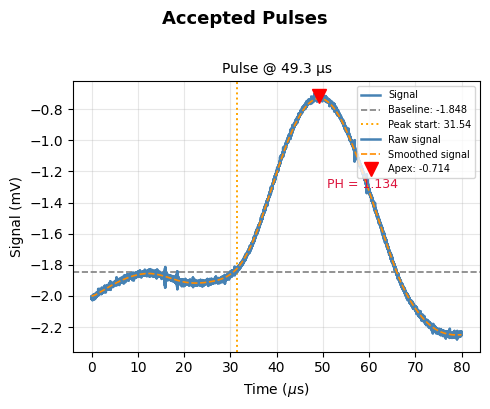

  Capture    92 | pulse height = 1.0952 mV


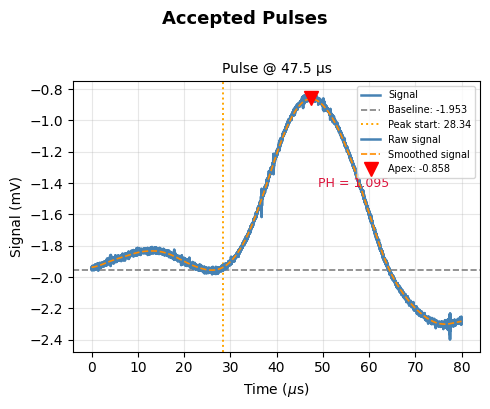

  Capture   169 | pulse height = 2.3199 mV


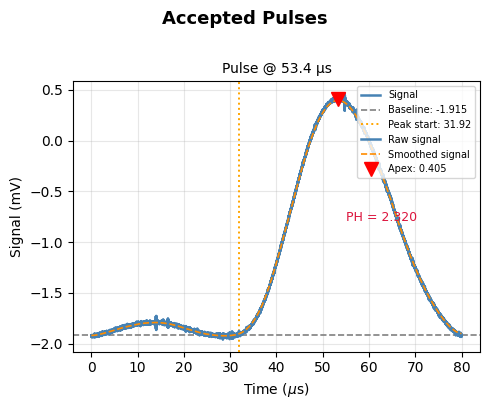

  Capture   237 | pulse height = 2.4461 mV


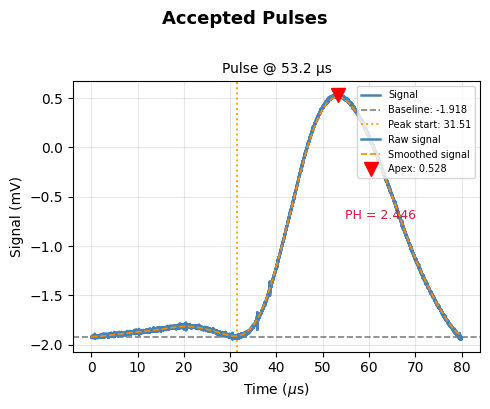

  Capture   279 | pulse height = 1.8850 mV


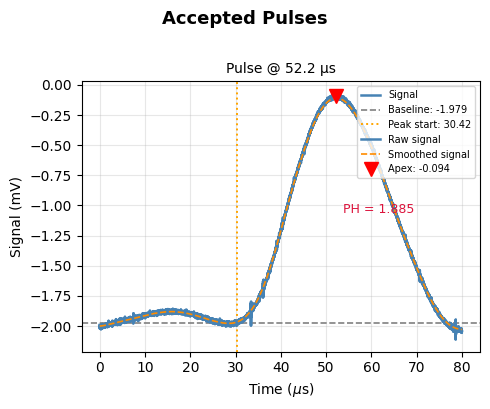

  Capture   329 | pulse height = 2.4929 mV


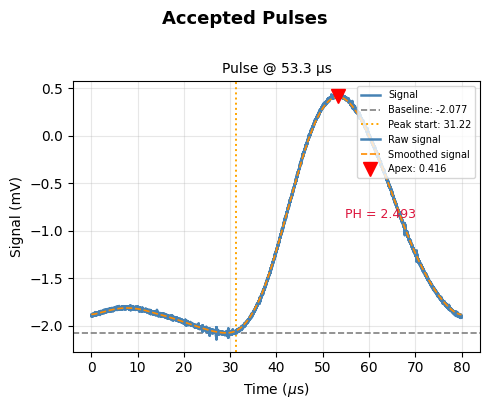

  Capture   391 | pulse height = 2.3183 mV


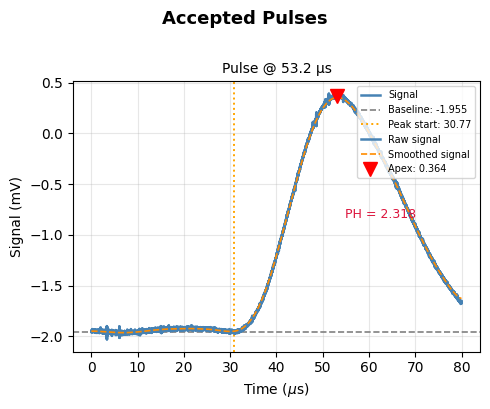

  Capture   468 | pulse height = 1.7866 mV


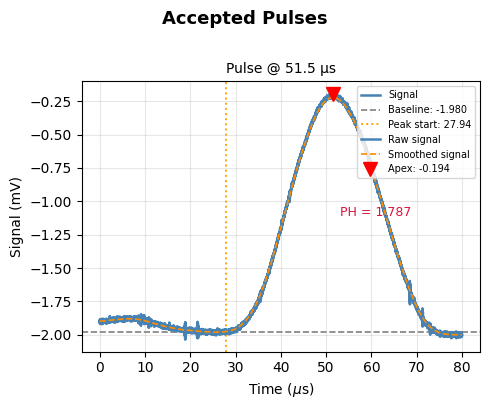

  Capture   522 | pulse height = 1.9734 mV


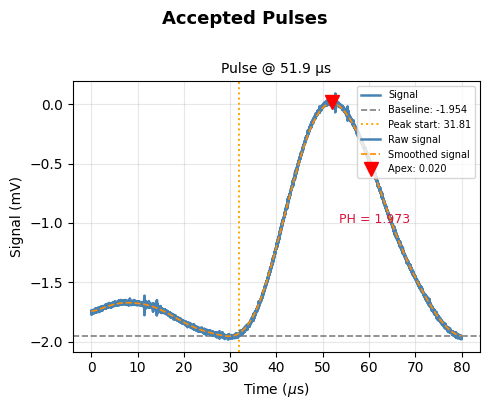

  Capture   590 | pulse height = 2.4967 mV


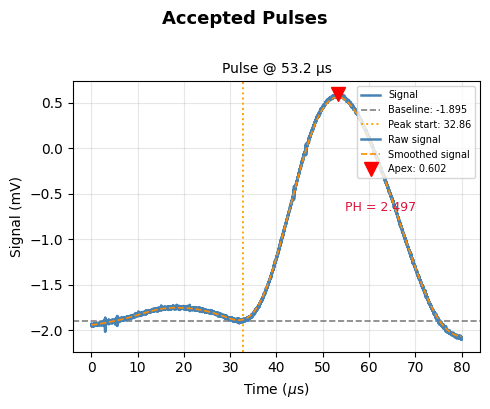

  Capture   627 | pulse height = 2.4358 mV


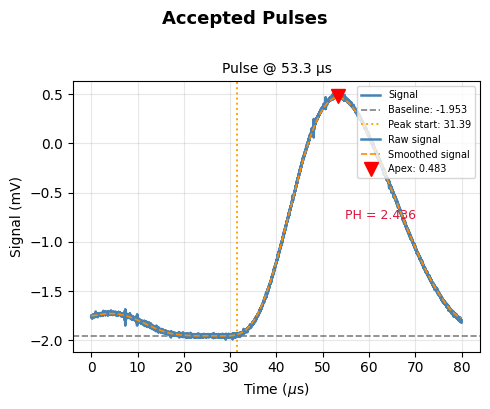

  Capture   703 | pulse height = 1.7093 mV


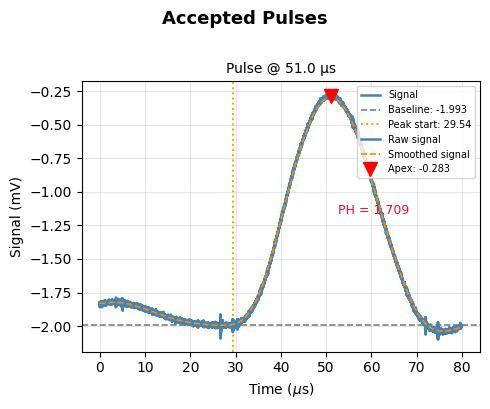

  Capture   749 | pulse height = 2.1556 mV


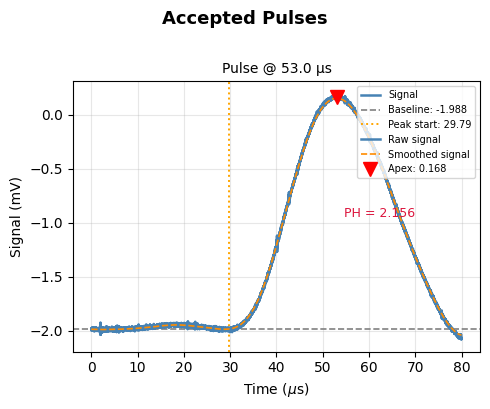

  Capture   819 | pulse height = 2.1031 mV


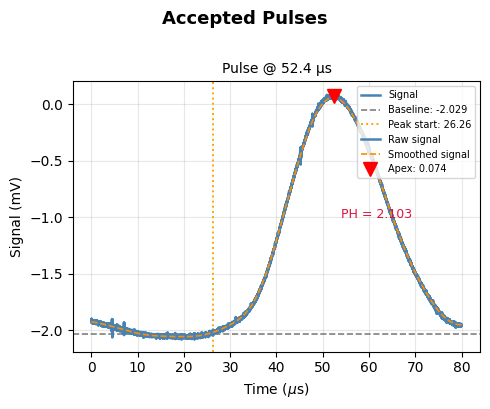

  Capture   884 | pulse height = 2.2074 mV


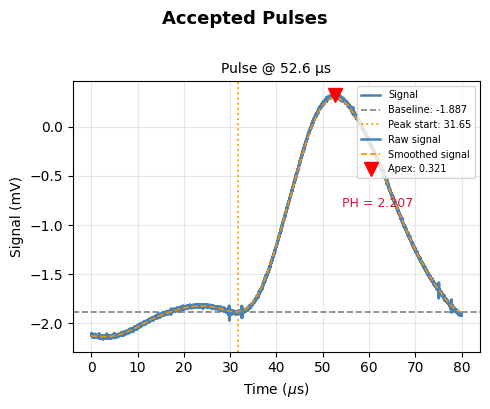

  Capture   953 | pulse height = 2.2291 mV


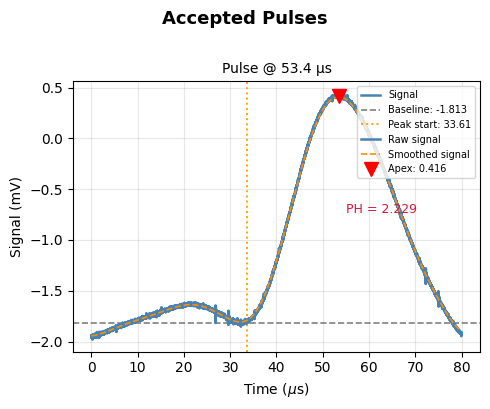

In [85]:
# ── Plot accepted pulses within the defined height range ──────────────────────
N_PLOTS = 16   # <-- how many pulses to plot (evenly spaced across the found set)

if len(in_range_indices) == 0:
    print("No pulses found in the specified range. Try adjusting PH_MIN / PH_MAX.")
else:
    # Evenly sample across the matched pulses
    sample_indices = np.linspace(0, len(in_range_indices) - 1, 
                                  min(N_PLOTS, len(in_range_indices)), dtype=int)

    for si in sample_indices:
        idx, ph = in_range_indices[si]
        print(f"  Capture {idx:>5d} | pulse height = {ph:.4f} mV")
        Shaping_amp.plot_accepted_pulses(
            data=ShapingAmpPulses_mV[idx],
            smoothed_data=SmoothedShapingPulses[idx],
            accepted_peaks=[int(PeakIndex[idx])],
            threshold=6,
            window_size=200,
            time_axis=Time_us,
        )

Saved: Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0248_PH_1.00_to_2.50_pulse_grid.png


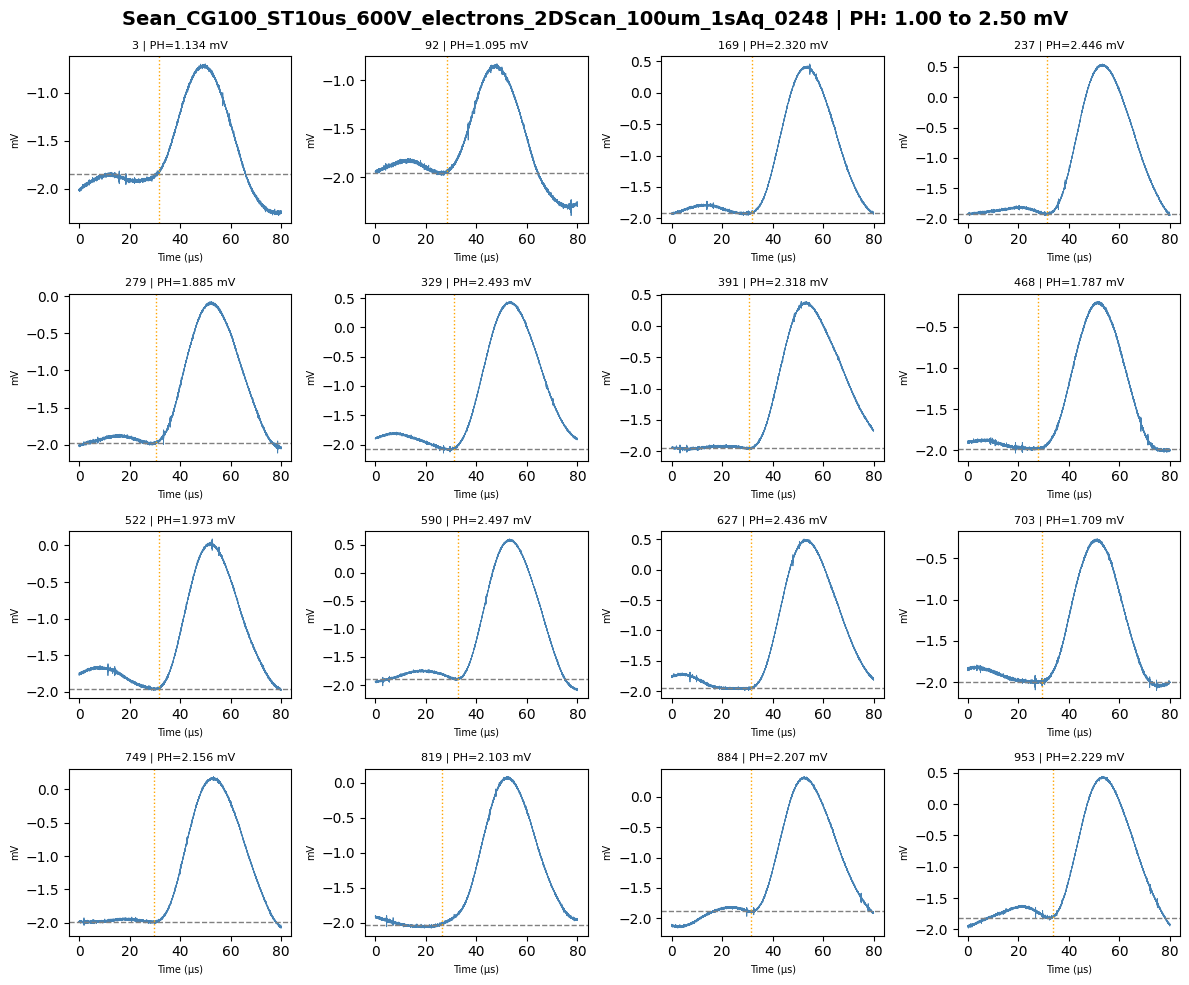

In [86]:
# ── 4x4 grid of accepted pulses + save as PNG ────────────────────────────────
import os

N_ROWS, N_COLS = 4, 4
N_PLOTS = N_ROWS * N_COLS

if len(in_range_indices) == 0:
    print("No pulses found in the specified range. Try adjusting PH_MIN / PH_MAX.")
else:
    sample_indices = np.linspace(
        0, len(in_range_indices) - 1,
        min(N_PLOTS, len(in_range_indices)),
        dtype=int
    )

    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 10), tight_layout=True)
    axes = axes.flatten()

    for ax, si in zip(axes, sample_indices):
        pulse_idx, ph = in_range_indices[si]
        raw = np.array(ShapingAmpPulses_mV[pulse_idx]).flatten()

        _, peak_start_idx, baseline, peak_value = Shaping_amp.find_pulse_height(
            raw_data             = raw,
            smoothed_data        = np.array(SmoothedShapingPulses[pulse_idx]).flatten(),
            peak_index           = int(PeakIndex[pulse_idx]),
            n_sigma              = 6,
            min_baseline_samples = 200,
            baseline_window      = 200,
        )

        ax.plot(Time_us, raw, linewidth=0.6, color='steelblue')
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.0)
        ax.axvline(Time_us[peak_start_idx], color='orange', linestyle=':', linewidth=1.0)
        ax.set_title(f"{pulse_idx} | PH={ph:.3f} mV", fontsize=8)
        ax.set_xlabel("Time (µs)", fontsize=7)
        ax.set_ylabel("mV", fontsize=7)

    for ax in axes[len(sample_indices):]:
        ax.axis('off')

    base_name = os.path.basename(filepath).replace('.hdf5', '')
    fig.suptitle(
        f"{base_name} | PH: {PH_MIN:.2f} to {PH_MAX:.2f} mV",
        fontsize=14, fontweight="bold"
    )

    save_path = f"{base_name}_PH_{PH_MIN:.2f}_to_{PH_MAX:.2f}_pulse_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved: {save_path}")
    plt.show()

In [87]:
# ── CELL -2: AlphaPlots function definition ───────────────────────────────────
def AlphaPlots(heights, Time_microsec, SampleName, nBinsPH):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5), tight_layout=True)
    ax.hist(heights, np.linspace(0, max(heights) * 1.1, num=nBinsPH))
    ax.set_xlabel("Pulse Height (mV)", fontsize=8, fontweight="bold")
    ax.set_ylabel("Frequency",         fontsize=8, fontweight="bold")
    ax.set_title(SampleName,           fontsize=8)
    ax.tick_params(axis='both', labelsize=8)
 
    ax.axvline(PH_MIN, color='red', linestyle='--', linewidth=1)
    ax.axvline(PH_MAX, color='red', linestyle='--', linewidth=1)
 
    plt.show()
 

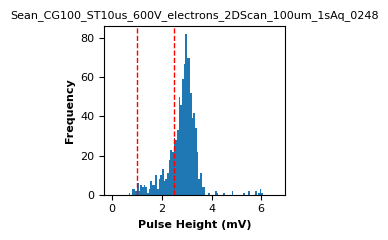

In [88]:
# ── CELL -1: Call AlphaPlots ──────────────────────────────────────────────────
AlphaPlots(heights, Time_us, os.path.basename(filepath).replace('.hdf5', ''), nBinsPH=100)